In [5]:
from prometheus_pandas import query
import datetime as dt
from zoneinfo import ZoneInfo
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

local_address = "nova-5.lyon.grid5000.fr"
local_port = "30090"
p = query.Prometheus(f"http://admin:prom-operator@{local_address}:{local_port}")    

local_tz = ZoneInfo("Europe/Paris")

def execute_query_range(experiment, metric_query, step, output_filename, plot=False):
    tput_series = []

    print("\nBeginning request execution")
    for label, config in experiment.items():    
        df_metric = p.query_range(
            query=metric_query,
            start=config['start'].isoformat(),
            end=config['end'].isoformat(),
            step=step
        )

        tput_series.append(df_metric)

    if tput_series:
        combined_df = pd.concat(tput_series, axis=1)
        combined_df.to_csv(output_filename, index_label='Time')
        print(f"\nFile saved : '{output_filename}'")
        if plot:
            plt.figure(figsize=(12, 8))
            ax = combined_df.boxplot(grid=True, patch_artist=True)
            plt.title(metric_query)
            plt.show()
    else:
        print("\nRequest Error")

In [ ]:
exp_q3 = {
    'rocks': {
        'start': dt.datetime(2025, 7, 25, 14, 43, 30, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 25, 14, 48, 30, tzinfo=local_tz)
    },
    'forst': {
        'start': dt.datetime(2025, 7, 25, 14, 52, 30, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 25, 14, 57, 30, tzinfo=local_tz)
    },
    'forst_small_cache': {
        'start': dt.datetime(2025, 7, 25, 15, 1, 30, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 25, 15, 6, 30, tzinfo=local_tz)
    },
    'forst_no_cache': {
        'start': dt.datetime(2025, 7, 25, 15, 10, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 25, 15, 15, 0, tzinfo=local_tz)
    }
}
exp_q5 = {
    'rocks': {
        'start': dt.datetime(2025, 7, 25, 16, 30, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 25, 16, 35, 0, tzinfo=local_tz)
    },
    'forst': {
        'start': dt.datetime(2025, 7, 25, 16, 47, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 25, 16, 52, 0, tzinfo=local_tz)
    },
    'forst_small_cache': {
        'start': dt.datetime(2025, 7, 25, 17, 5, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 25, 17, 10, 0, tzinfo=local_tz)
    },
    'forst_no_cache': {
        'start': dt.datetime(2025, 7, 25, 17, 23, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 25, 17, 28, 0, tzinfo=local_tz)
    }
}
exp_q8 = {
    'rocks': {
        'start': dt.datetime(2025, 7, 28, 14, 49, 30, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 28, 14, 54, 30, tzinfo=local_tz)
    },
    'forst': {
        'start': dt.datetime(2025, 7, 28, 14, 57, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 28, 15, 2, 0, tzinfo=local_tz)
    },
    'forst_small_cache': {
        'start': dt.datetime(2025, 7, 28, 15, 5, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 28, 15, 10, 0, tzinfo=local_tz)
    },
    'forst_no_cache': {
        'start': dt.datetime(2025, 7, 28, 15, 12, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 28, 15, 17, 0, tzinfo=local_tz)
    }
}

exp_q11 = {
    'rocks': {
        'start': dt.datetime(2025, 7, 29, 10, 35, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 29, 10, 40, 0, tzinfo=local_tz)
    },
    'forst': {
        'start': dt.datetime(2025, 7, 29, 10, 56, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 29, 11, 1, 0, tzinfo=local_tz)
    },
    'forst_small_cache': {
        'start': dt.datetime(2025, 7, 29, 11, 13, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 29, 11, 18, 0, tzinfo=local_tz)
    },
    'forst_no_cache': {
        'start': dt.datetime(2025, 7, 29, 11, 33, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 7, 29, 11, 38, 0, tzinfo=local_tz)
    }
}

In [ ]:
metric_query = 'flink_taskmanager_Status_JVM_CPU_Load{component="taskmanager"}'
step = "5s"
output_filename = 'exp2b_q3_cpu_load.csv'
execute_query_range(exp_q3, metric_query, step, output_filename)

metric_query = 'flink_jobmanager_job_lastCheckpointDuration{component="jobmanager"}'
step = "30s"
output_filename = 'exp2b_q3_cp_time.csv'
execute_query_range(exp_q3, metric_query, step, output_filename)

metric_query = 'sum(rate(container_network_receive_bytes_total{namespace="minio-tenant", pod=~"myminio-.*"}[5m]))'
step = "5s"
output_filename = 'exp2b_q3_minio_bytes.csv'
execute_query_range(exp_q3, metric_query, step, output_filename)


Beginning request execution

File saved : 'exp2a_q11_tput.csv'


### BoxPlot

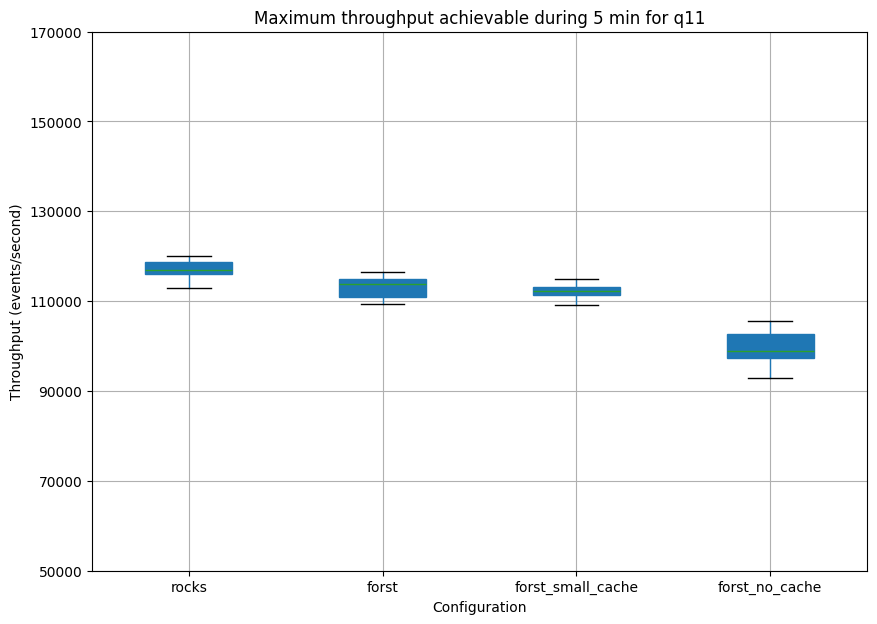

In [ ]:
file_path = 'exp2b_q3_tput.csv'

try:
    df = pd.read_csv(file_path, index_col=0)
    
    df.columns = ['rocks', 'forst', 'forst_small_cache', 'forst_no_cache']
    
    plt.figure(figsize=(10, 7))
    df.boxplot(grid=True, patch_artist=True)
    
    plt.title('Maximum throughput achievable during 5 min for q11')
    plt.ylabel('Throughput (events/second)')
    plt.xlabel('Configuration')
    plt.yticks(np.arange(50000, 180000, 20000))
    plt.savefig('boxplot_q11.png')
    plt.show()
    
except FileNotFoundError:
    print(f"Le fichier '{file_path}' est introuvable.")
except Exception as e:
    print(f"Une erreur est survenue : {e}")